In [7]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

In [2]:
df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
print(df.head())
print("\n\n----------------------------------------------------------\n\n")
print(df.shape)

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

In [3]:
def get_df():
    df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
    return df

def rm_empty_rows(df):
    df = df.copy()
    df = df.dropna()
    return df

def seperate_target(df):
    df = df.copy()
    cols = df.columns
    cols = list(cols)
    cols.remove("Diabetes_binary")
    target = df.drop(cols,axis=1,inplace=False)
    df.drop('Diabetes_binary', axis=1, inplace=True)
    return (target, df)


def standardization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.StandardScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df


def normalization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.M|inMaxScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df

def get_split(target, df, test_size):
    df = df.copy()
    x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(df,target,test_size=test_size,random_state=42)
    return (x_train, x_test, y_train, y_test)

    
def get_regression_scores(y_test,y_pred):
    r2 = sk.metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
    mae = sk.metrics.mean_absolute_error(y_test, y_pred)
    return (r2, rmse, mae)
    

In [4]:

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)

print(df.head())
for col in df.columns:
    print(f"{col}")
    print(df[col].unique())

     HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
0  1.153688  1.165254   0.196922  1.757936  1.120927 -0.205637   
1 -0.866785 -0.858182  -5.078164 -0.511806  1.120927 -0.205637   
2  1.153688  1.165254   0.196922 -0.057858 -0.892119 -0.205637   
3  1.153688 -0.858182   0.196922 -0.209174 -0.892119 -0.205637   
4  1.153688  1.165254   0.196922 -0.663122 -0.892119 -0.205637   

   HeartDiseaseorAttack  PhysActivity    Fruits   Veggies  ...  AnyHealthcare  \
0             -0.322458     -1.762814 -1.316872  0.482087  ...       0.226863   
1             -0.322458      0.567275 -1.316872 -2.074316  ...      -4.407954   
2             -0.322458     -1.762814  0.759375 -2.074316  ...       0.226863   
3             -0.322458      0.567275  0.759375  0.482087  ...       0.226863   
4             -0.322458      0.567275  0.759375  0.482087  ...       0.226863   

   NoDocbcCost   GenHlth  MentHlth  PhysHlth  DiffWalk       Sex       Age  \
0    -0.303173  2.329121  1.998592  1.

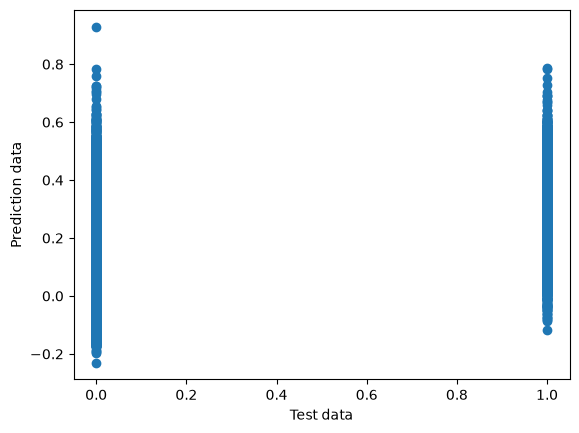

R2 score: 0.16269021365974257
RMSE score: 0.31551297282623975
MAE score: 0.2159971455858634


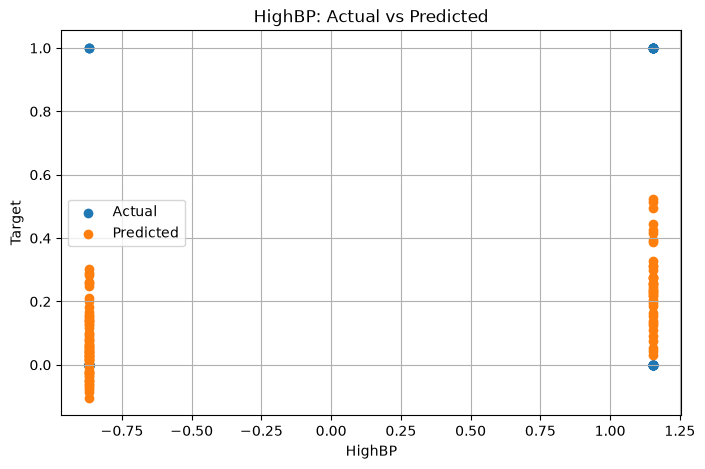

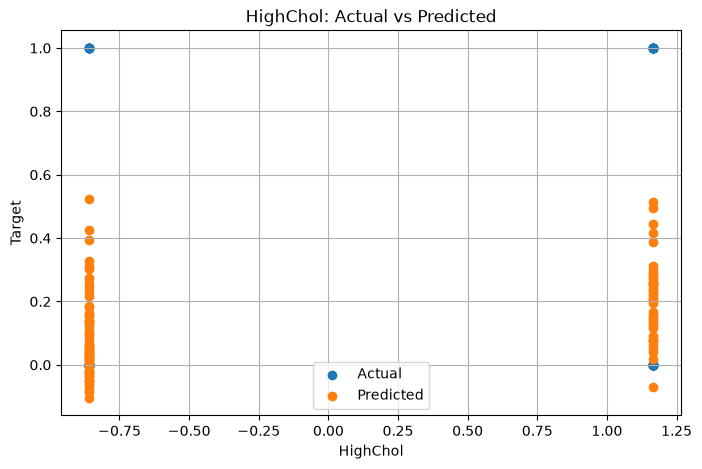

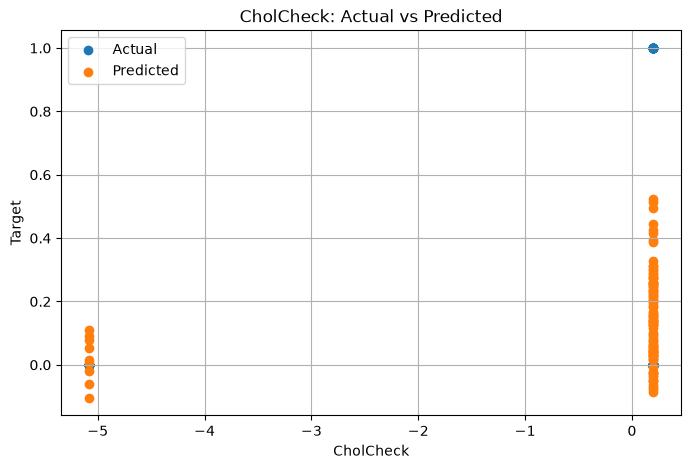

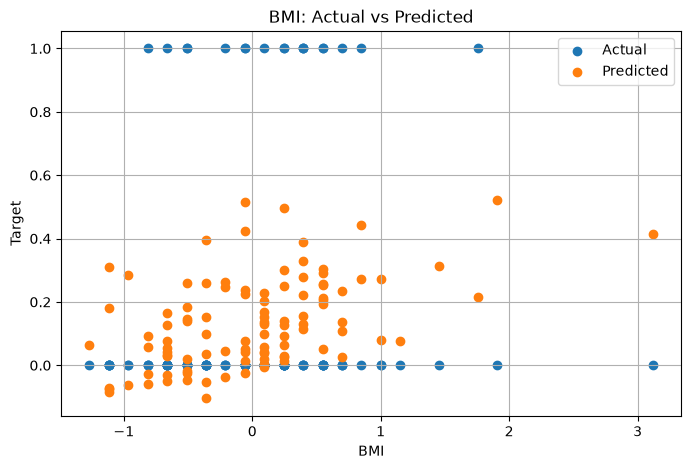

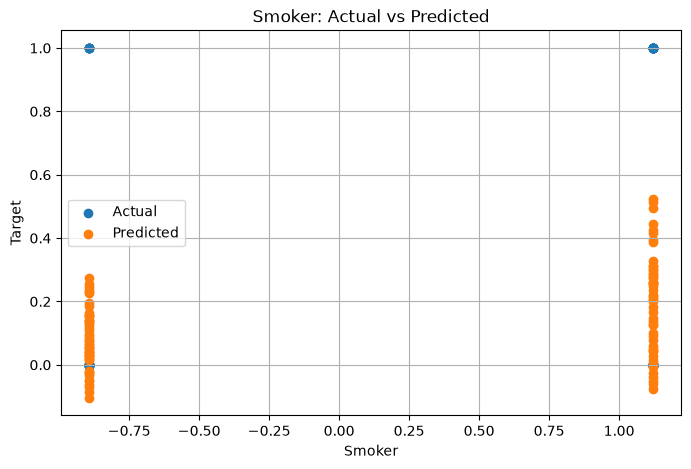

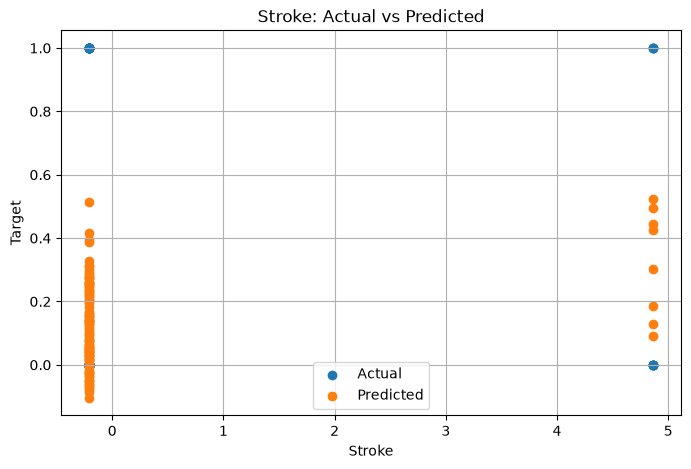

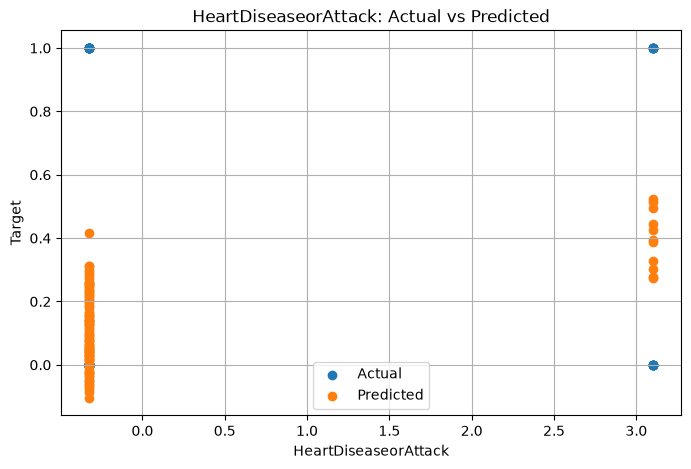

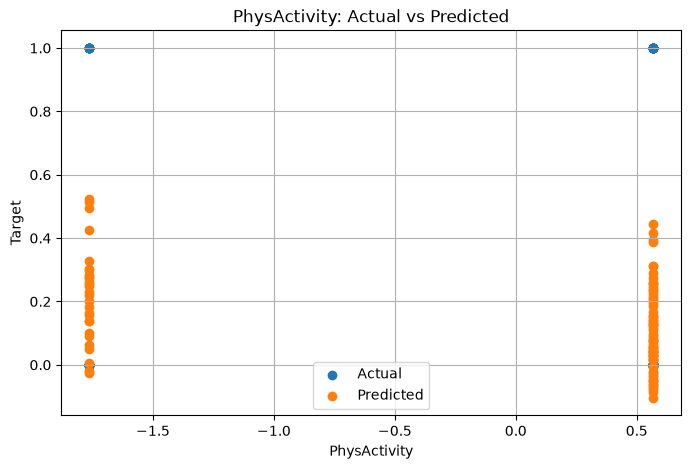

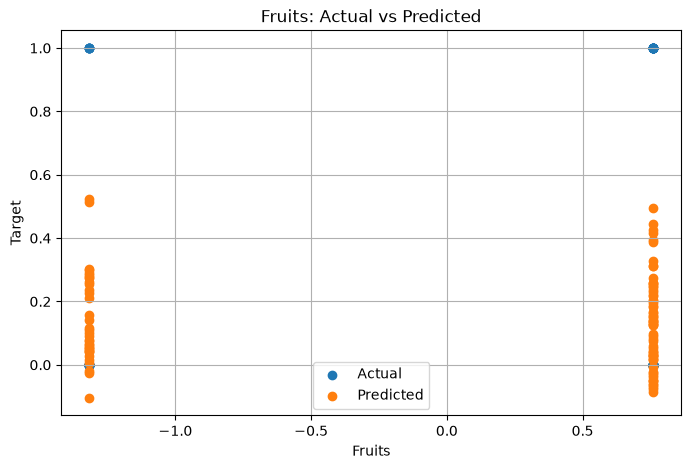

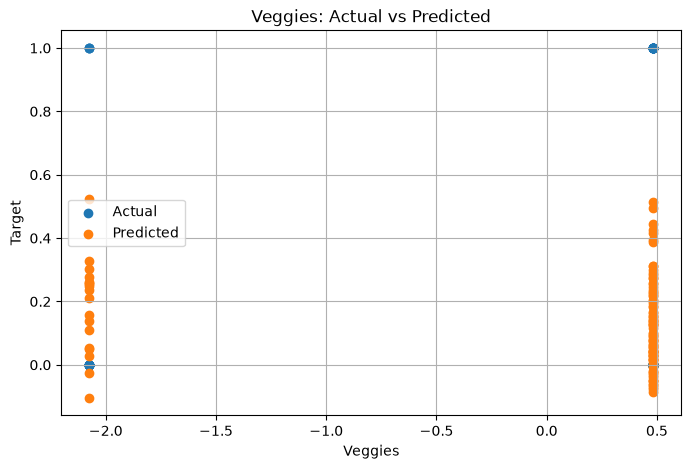

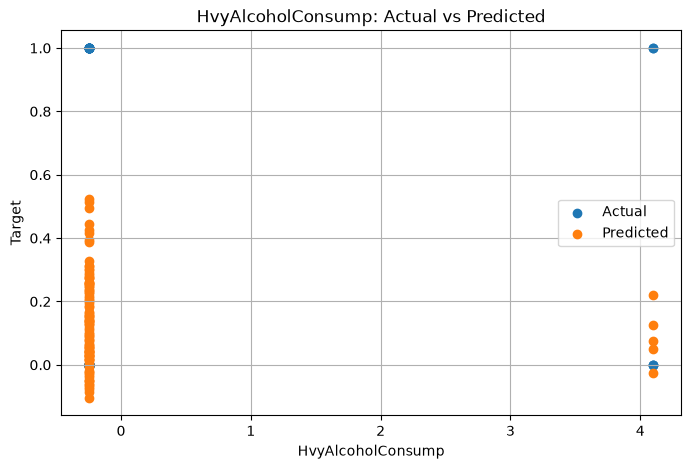

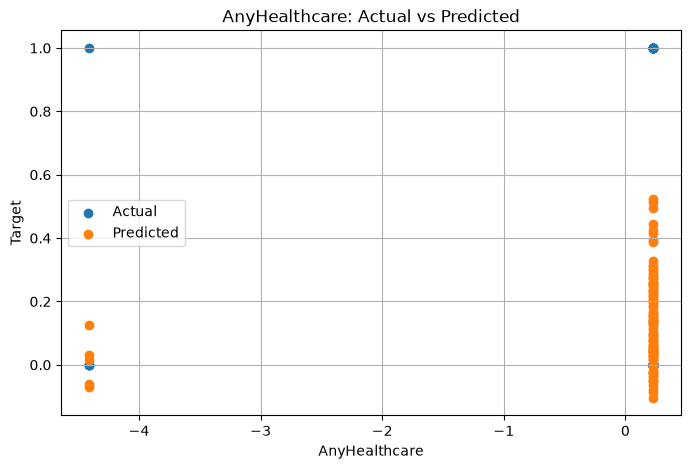

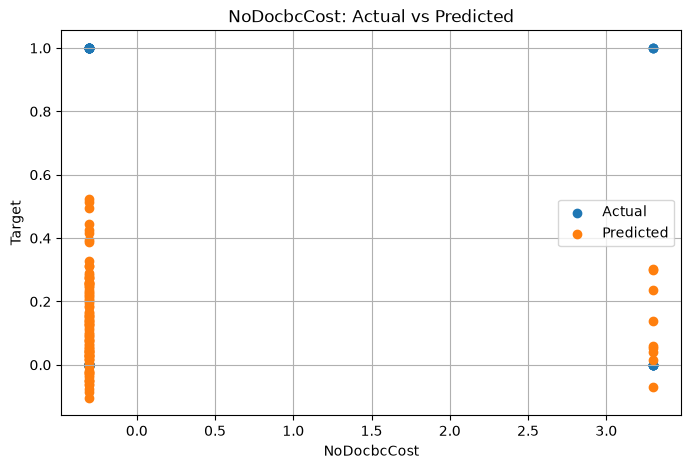

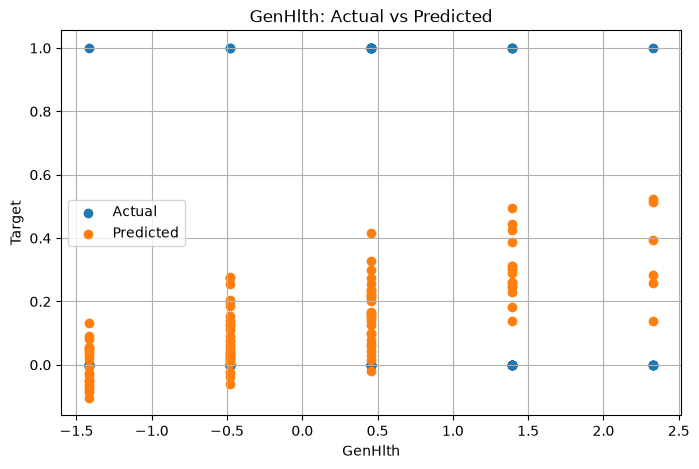

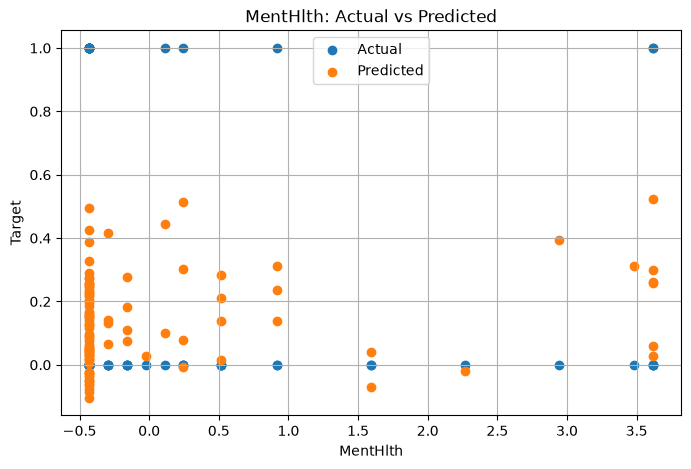

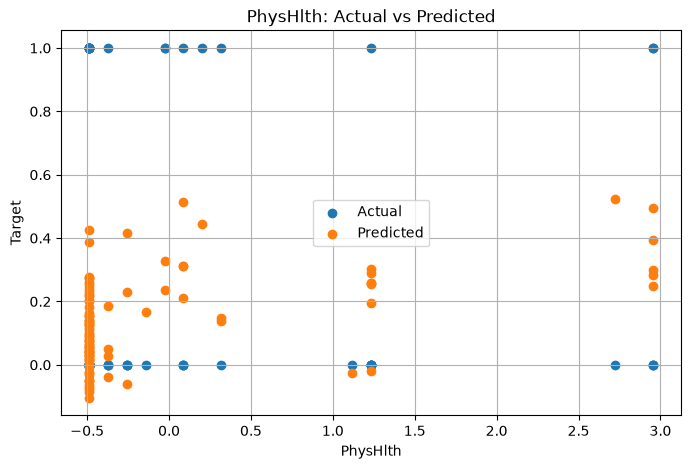

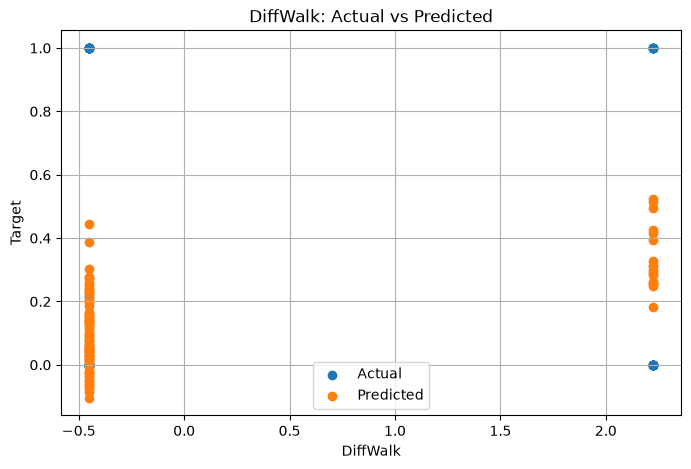

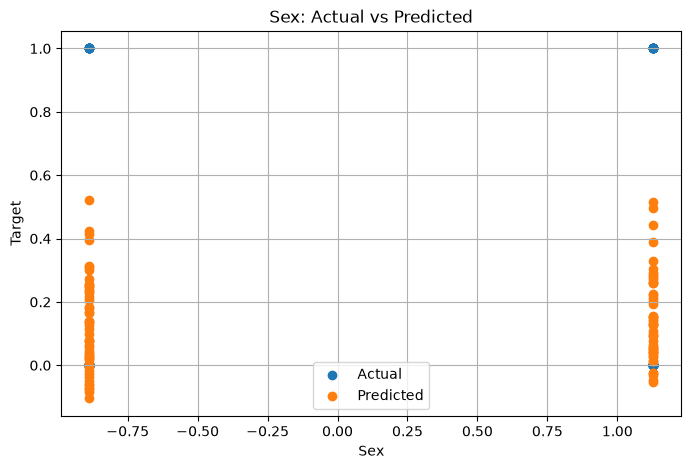

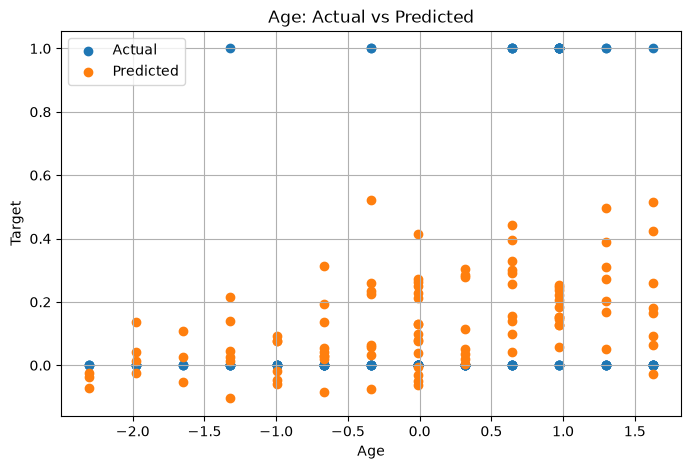

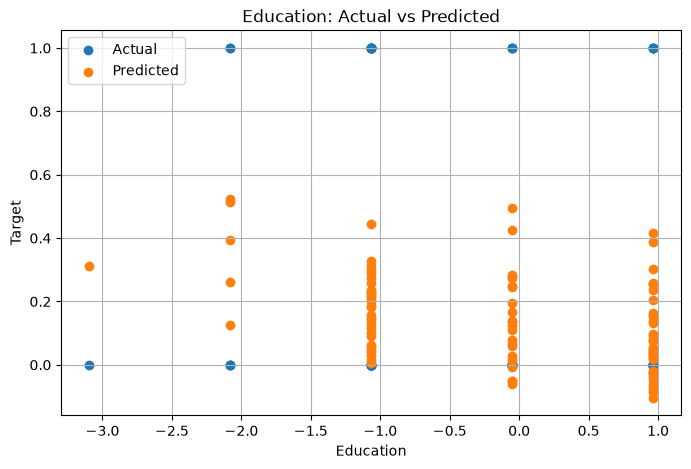

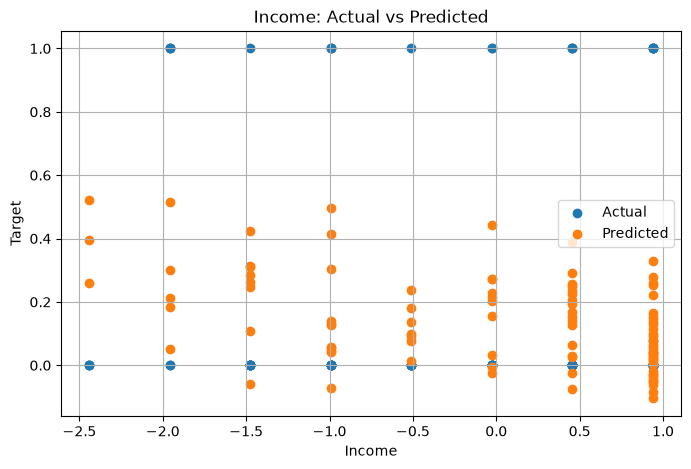

In [29]:
# Linear regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)

df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)
model = sk.linear_model.LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.show()

r2, rmse, mae = get_regression_scores(y_test,y_pred)
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")


max_points = 100
n_points = min(max_points, len(x_test))

# Randomly select indices
random_indices = np.random.choice(
    len(x_test),
    size=n_points,
    replace=False
)

for feature in x_test.columns:

    plt.figure(figsize=(8, 5))

    x_values = x_test[feature].iloc[random_indices]
    actual = y_test.iloc[random_indices]
    predicted = y_pred[random_indices]

    plt.scatter(x_values, actual, label="Actual")
    plt.scatter(x_values, predicted, label="Predicted")

    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature}: Actual vs Predicted")

    plt.legend()
    plt.grid(True)
    plt.show()


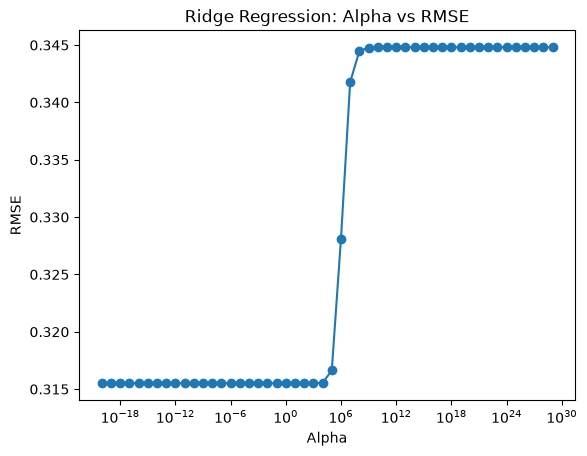

Least RMSE value: 0.3155129728262397
Coresponding learning rate: 1.0000000000000002e-10


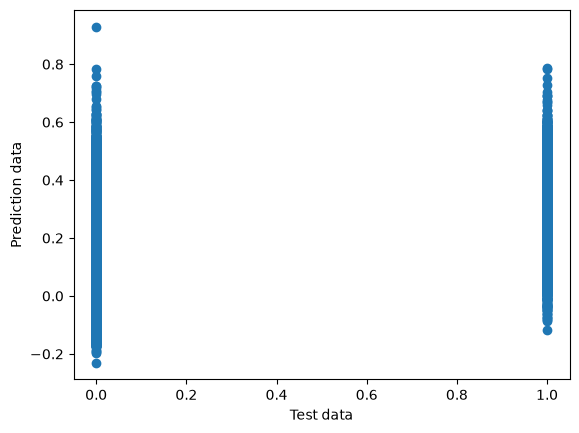

R2 score: 0.16269021365974268
RMSE score: 0.3155129728262397
MAE score: 0.21599714558586353


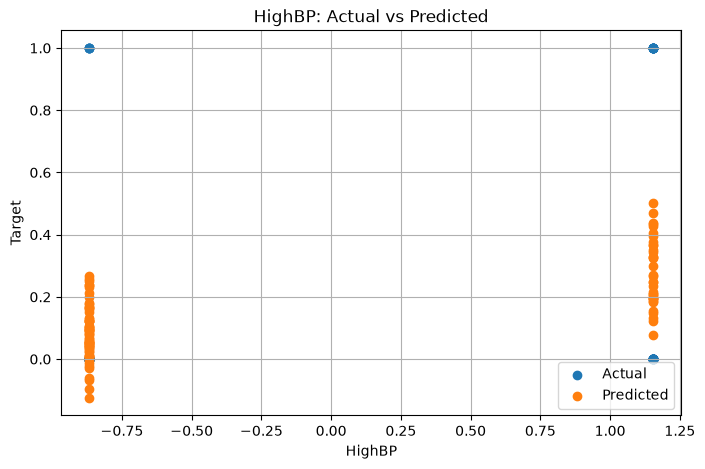

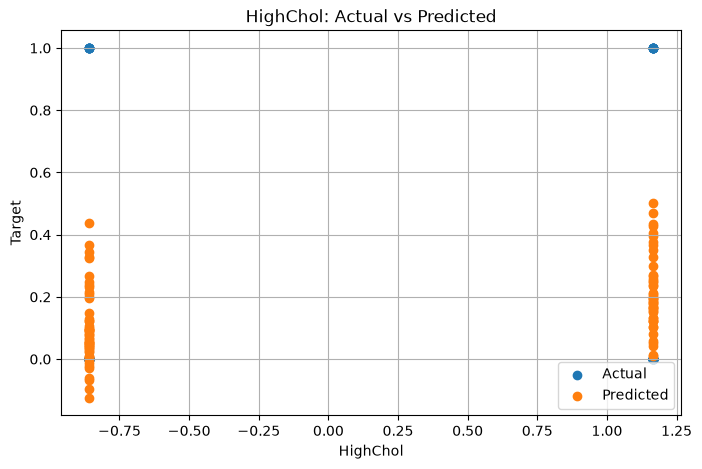

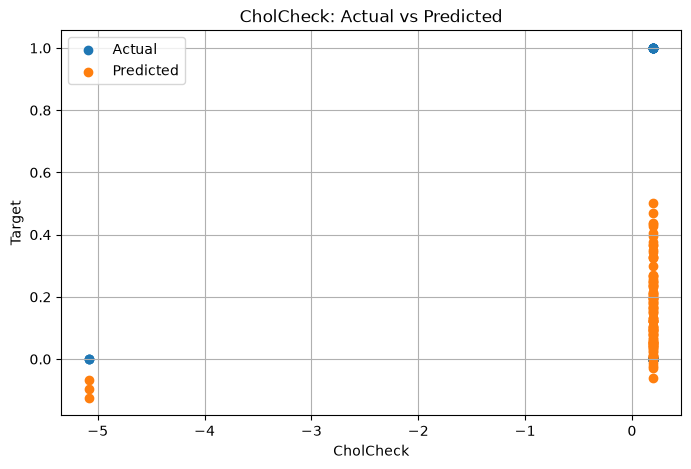

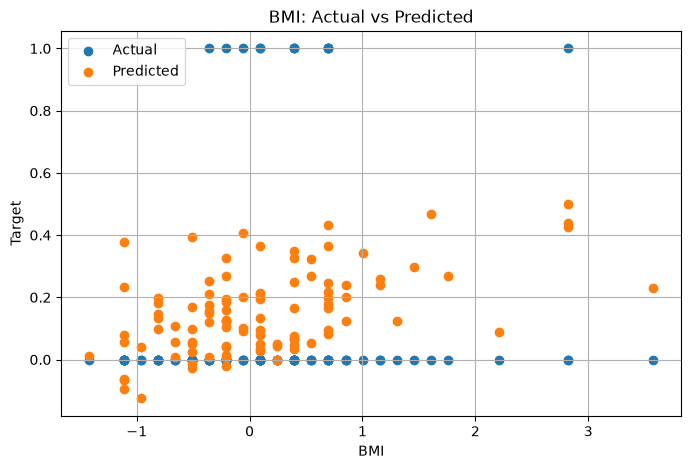

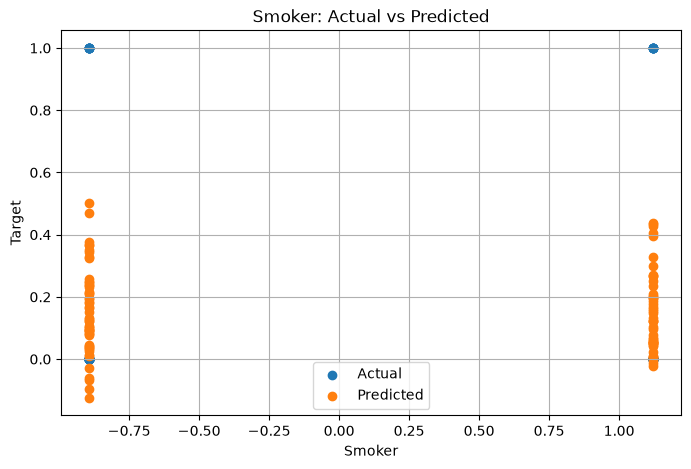

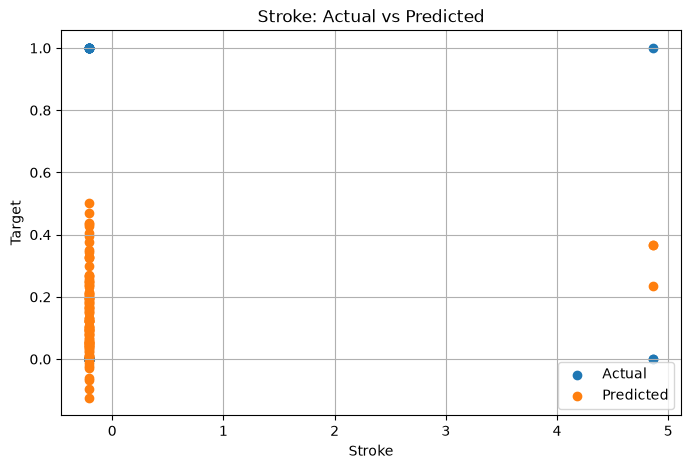

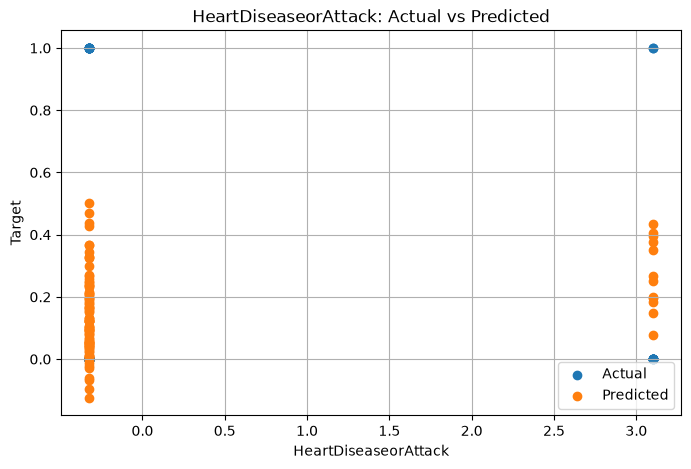

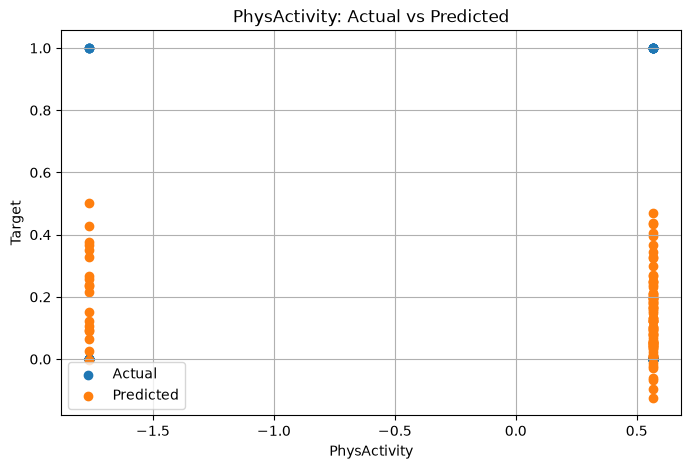

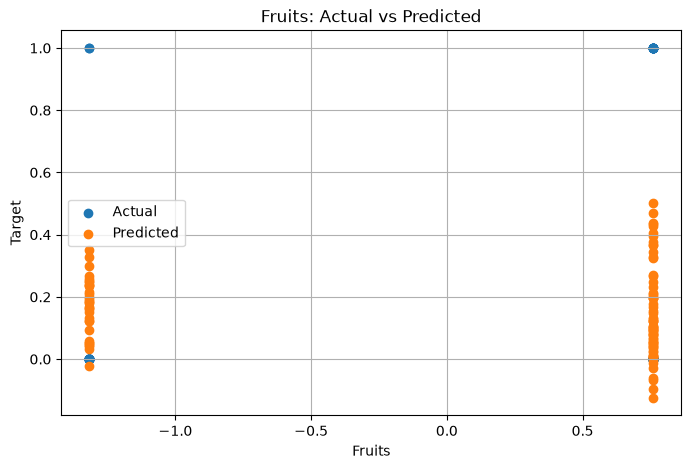

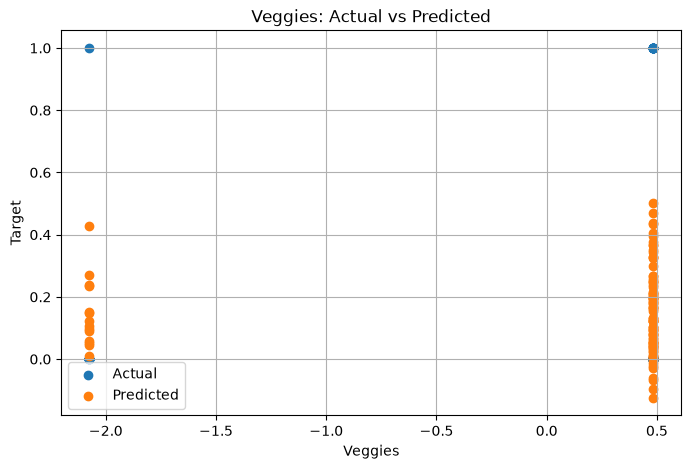

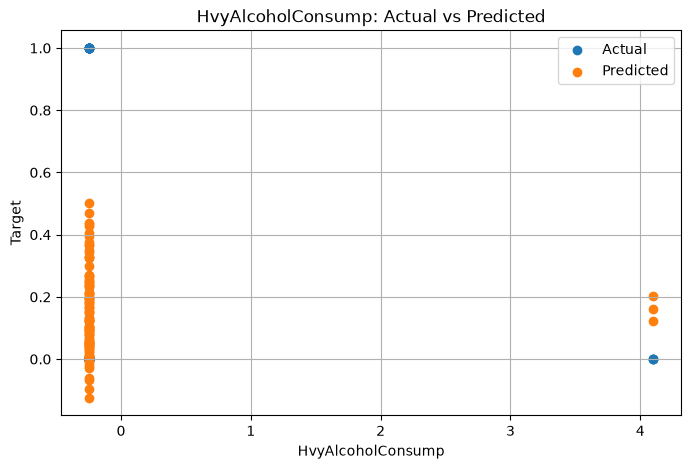

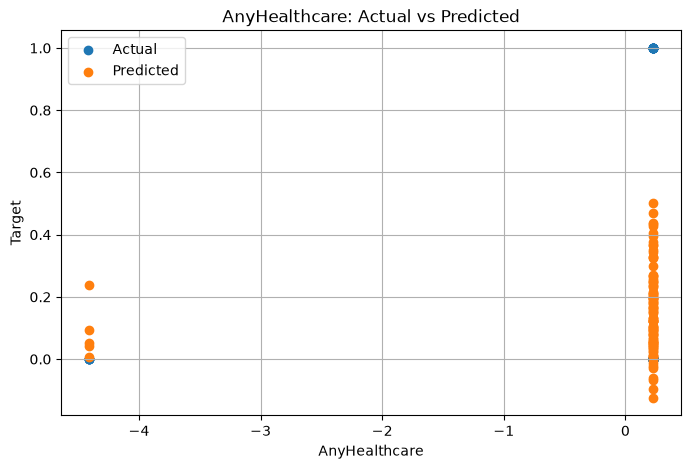

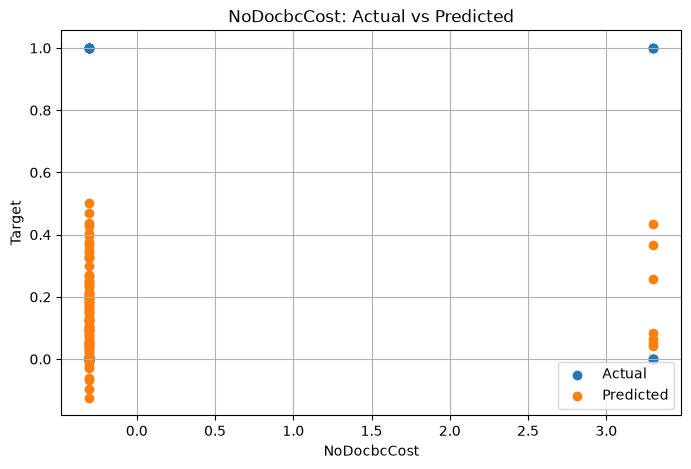

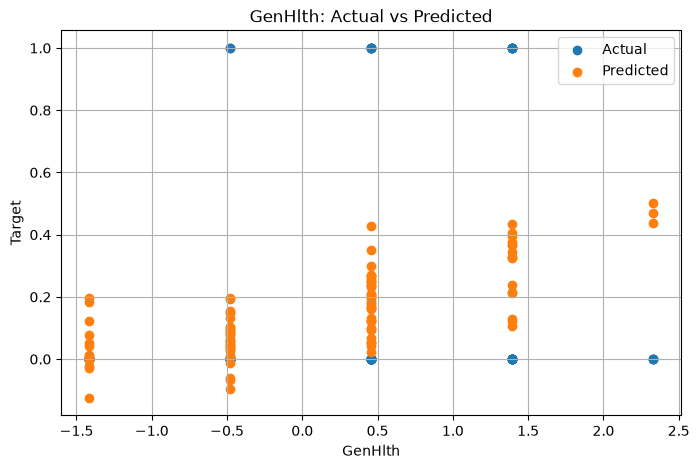

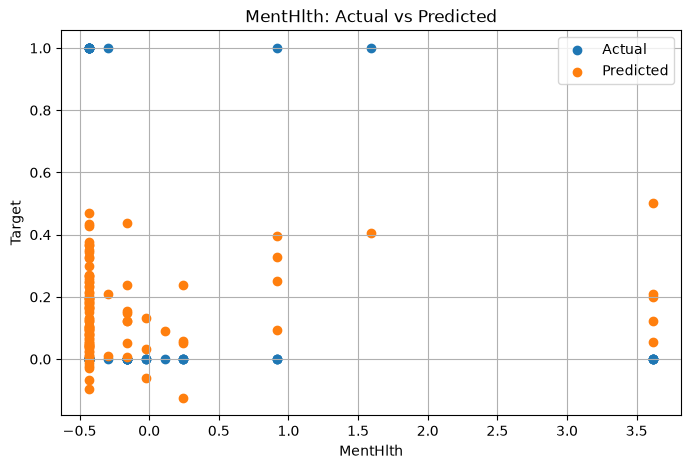

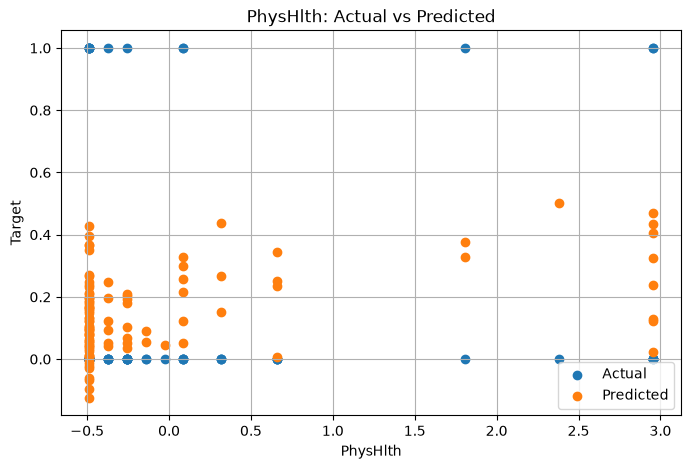

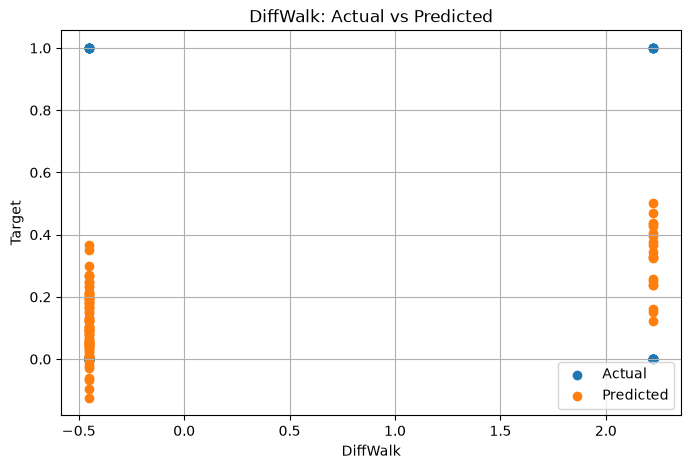

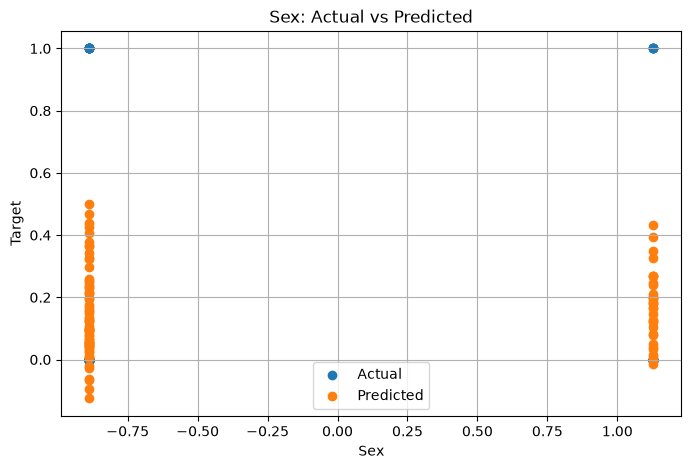

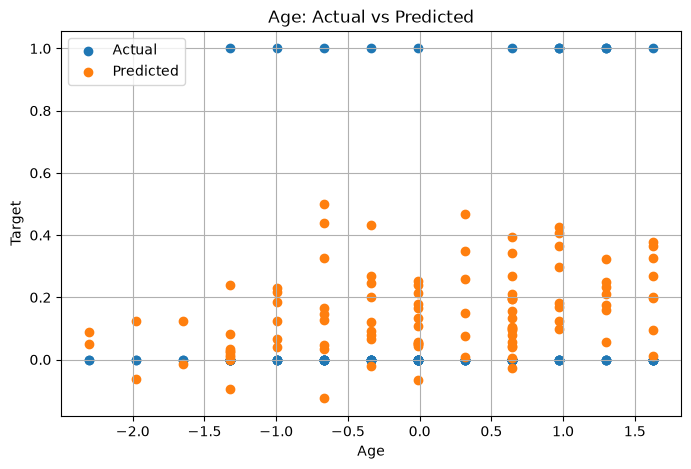

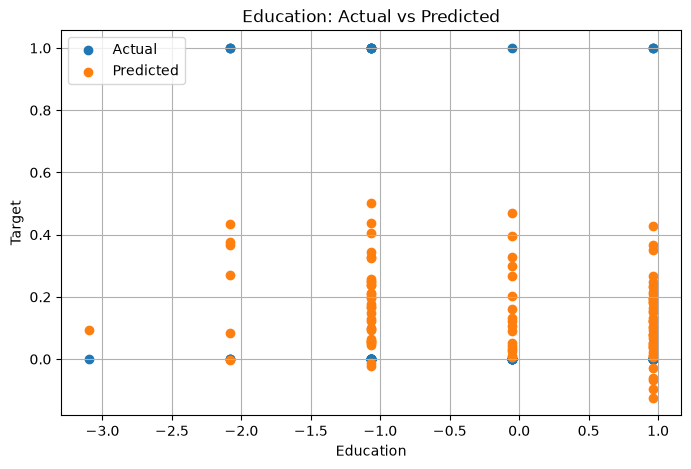

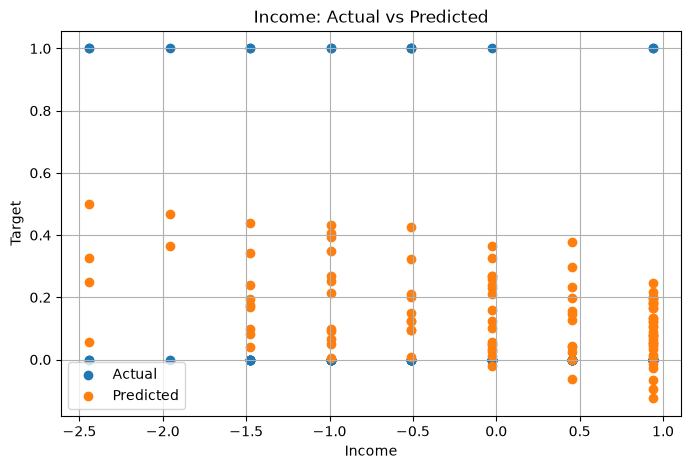

In [28]:
# Ridge regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

alphas = []

rmse_values = []
alpha = 10**(-20)
for _ in range(50):
    alphas.append(alpha)
    model = sk.linear_model.Ridge(alpha=alpha)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    _, rmse, _ = get_regression_scores(y_test, y_pred)

    rmse_values.append(rmse)
    alpha*= 10
    

plt.plot(alphas, rmse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Alpha vs RMSE")
plt.show()

lowest_rmse = min(rmse_values)
ind_lowest_rmse = rmse_values.index(lowest_rmse)
most_accurate_alpha = alphas[ind_lowest_rmse]
print(f"Least RMSE value: {lowest_rmse}")
print(f"Coresponding learning rate: {most_accurate_alpha}")


model = sk.linear_model.Ridge(alpha=most_accurate_alpha)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.show()

r2, rmse, mae = get_regression_scores(y_test,y_pred)
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")


max_points = 100
n_points = min(max_points, len(x_test))

# Randomly select indices
random_indices = np.random.choice(
    len(x_test),
    size=n_points,
    replace=False
)

for feature in x_test.columns:

    plt.figure(figsize=(8, 5))

    x_values = x_test[feature].iloc[random_indices]
    actual = y_test.iloc[random_indices]
    predicted = y_pred[random_indices]

    plt.scatter(x_values, actual, label="Actual")
    plt.scatter(x_values, predicted, label="Predicted")

    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"{feature}: Actual vs Predicted")

    plt.legend()
    plt.grid(True)
    plt.show()


alpha=1e-05  zero features=0   non-zero features=21
alpha=0.0001 zero features=1   non-zero features=20
alpha=0.001  zero features=2   non-zero features=19
alpha=0.01   zero features=10  non-zero features=11
alpha=0.1    zero features=20  non-zero features=1


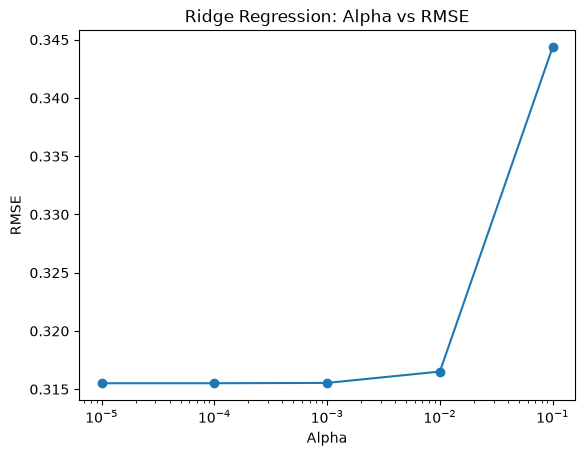

Least RMSE value: 0.3155130135515165
Coresponding learning rate: 1e-05


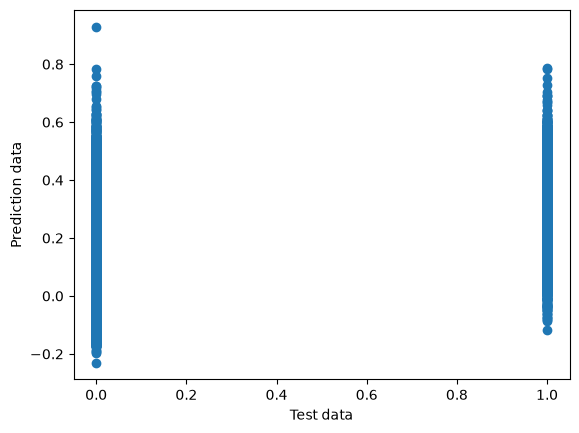

R2 score: 0.16269021365969583
RMSE score: 0.31551297282624857
MAE score: 0.21599714558514607


In [16]:
# Lasso regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)

alphas = []

rmse_values = []


alpha = 10**(-5)
for _ in range(5):
    alphas.append(alpha)
    model = sk.linear_model.Lasso(alpha=alpha)
    model.fit(x_train, y_train)

    zero = (model.coef_ == 0).sum()

    print(
        f"alpha={alpha:<6} "
        f"zero features={zero:<3} "
        f"non-zero features={len(model.coef_) - zero}"
    )

    
    y_pred = model.predict(x_test)

    _, rmse, _ = get_regression_scores(y_test, y_pred)

    rmse_values.append(rmse)


    

    alpha*=10

    
plt.plot(alphas, rmse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Alpha vs RMSE")
plt.show()

lowest_rmse = min(rmse_values)
ind_lowest_rmse = rmse_values.index(lowest_rmse)
most_accurate_alpha = alphas[ind_lowest_rmse]
print(f"Least RMSE value: {lowest_rmse}")
print(f"Coresponding learning rate: {most_accurate_alpha}")


model = sk.linear_model.Ridge(alpha=most_accurate_alpha)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.show()

r2, rmse, mae = get_regression_scores(y_test,y_pred)
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")
print(f"MAE score: {mae}")



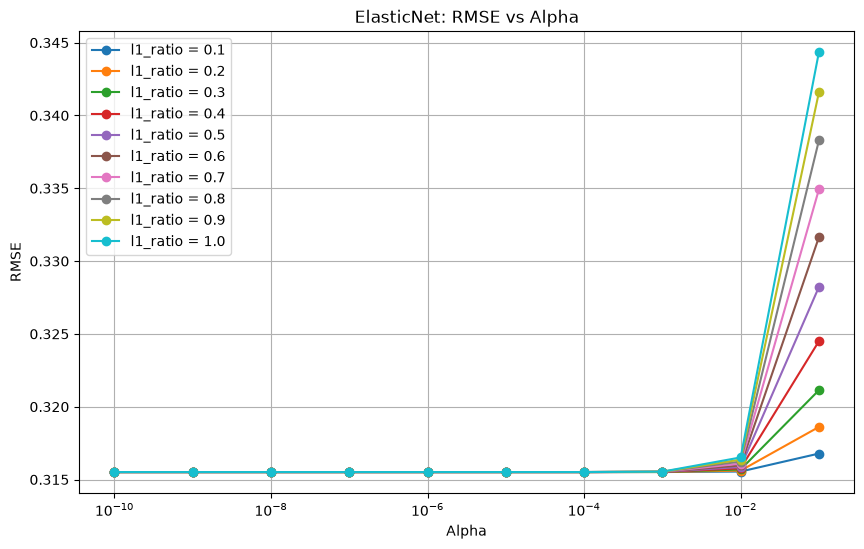

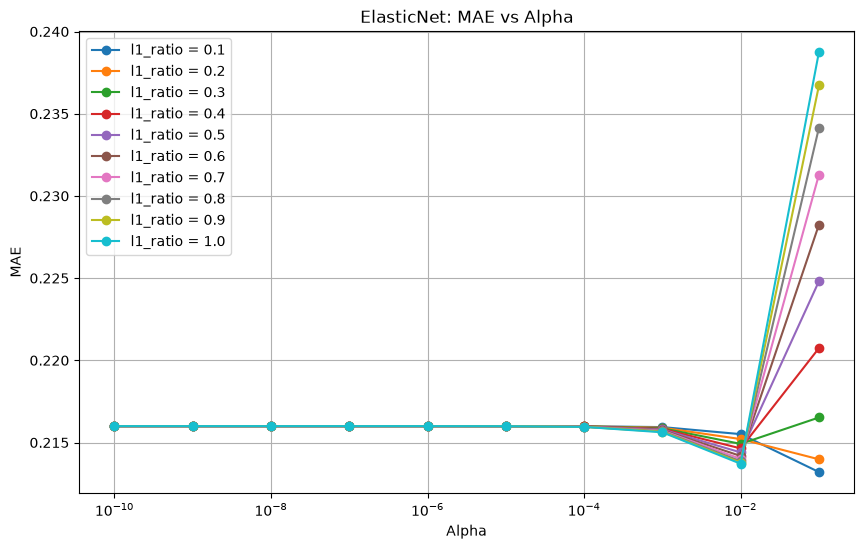

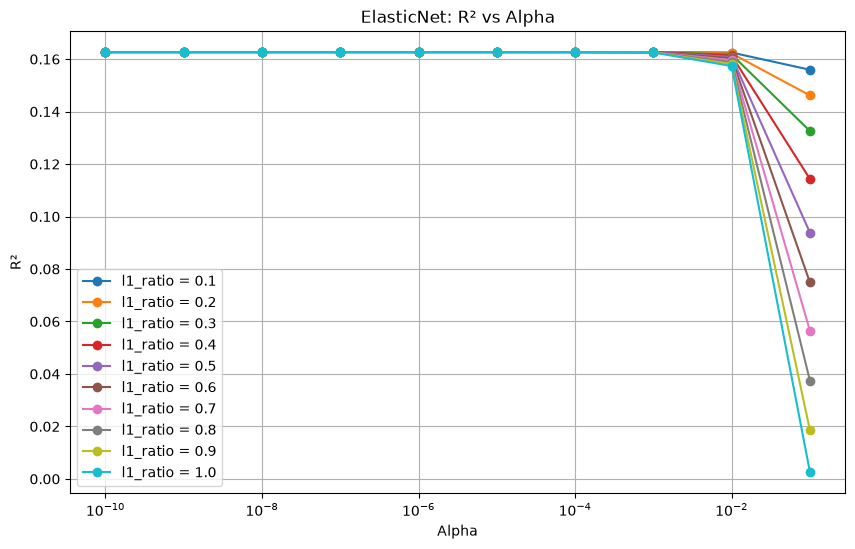

In [11]:
# ElasticNet regression

SPLIT_TEST_SIZE = 0.2

df = get_df()
df = rm_empty_rows(df)
target, df = seperate_target(df)
df = standardization(df, df.columns)
x_train,x_test, y_train,y_test = get_split(target,df,SPLIT_TEST_SIZE)


results = [] #each element: (l1_ratio, alpha, rmse, mae, r2)
alpha = 10**(-10)
l1_ratio = 0.1

for _ in range(10):
    alpha = 10**(-10)
    for _ in range(10):
        model_path = f"../models/elasticNet_l1_ratio_{l1_ratio}_alpha_{alpha}.pkl"
        if os.path.exists(model_path):
            model = joblib.load(model_path)
        else:
            model = sk.linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
            model.fit(x_train,y_train)
            joblib.dump(model, model_path)
        y_pred = model.predict(x_test)
        r2, rmse, mae = get_regression_scores(y_test,y_pred)
        results.append((l1_ratio,alpha, rmse, mae, r2))
        alpha*=10
    l1_ratio+=0.1


results = np.array(results)

l1_ratios = results[:, 0]
alphas = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]
r2 = results[:, 4]

plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        rmse[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("ElasticNet: RMSE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# MAE plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        mae[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("ElasticNet: MAE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# R² plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        r2[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("ElasticNet: R² vs Alpha")
plt.legend()
plt.grid(True)

plt.show()